# Creating quarter-hour weather data

This notebook combines all station files, preserves the original hourly observations, derives quarter-hour estimates, writes parquet, and visualizes the result.

**Important:** the source contains hourly data only. Quarter-hour values are estimates, not measured 15-minute weather. Continuous readings are linearly interpolated only between valid adjacent hourly records. Hourly precipitation and sunshine totals are divided evenly across four quarters to conserve each hourly total; that cannot recover when rain or sunshine actually occurred. Source values at each original hour are retained unchanged.

In [ ]:
pip install plotly

In [3]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / 'src_weather').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import importlib
import src_weather.resampling as weather_resampling
importlib.reload(weather_resampling)
import src_weather.pipeline as weather_pipeline
importlib.reload(weather_pipeline)
import src_weather.visualization as weather_visualization
importlib.reload(weather_visualization)
import pandas as pd
from IPython.display import display

from src_weather.io import read_weather_files, read_variable_overview
from src_weather.resampling import classify_variables, to_quarter_hourly, quarter_total_column_name, quarter_source_column_name
from src_weather.pipeline import write_weather_parquet
from src_weather.visualization import plot_all_variables, plot_variable_coverage, plot_granularity_comparison
from src_weather.visualization import plot_all_variables_matplotlib, plot_variable_coverage_matplotlib

INPUT_DIR = ROOT / 'data/weather_data_hourly'
OVERVIEW = ROOT / 'data/weather_data_overview/weather_variables.csv'
OUTPUT = ROOT / 'data/weather_data_15min/weather_data_15min.parquet'

## 1. Review the variable dictionary and station coverage

The overview describes variables and availability. The input files contain the hourly measures; daily variables in the dictionary are not present in these hourly CSVs, so this process does not synthesize daily-only variables.

In [4]:
metadata = read_variable_overview(OVERVIEW)
hourly = read_weather_files(INPUT_DIR)
display(metadata)
print(f'{len(list(INPUT_DIR.glob("*.csv")))} files, {hourly.Weather_ID.nunique()} stations, {len(hourly):,} hourly rows')
print('All hourly columns:', hourly.columns.tolist())
display(hourly.groupby('Weather_ID').agg(rows=('Timestamp','size'), start=('Timestamp','min'), end=('Timestamp','max')))

,VariableName,ParameterGroup,Resolution,Unit,Description
0,Temperature_avg_hourly,temperature,hourly,degrees Celsius,Air temperature 2 m above ground - hourly average
1,Temperature_max_daily,temperature,daily,degrees Celsius,Air temperature 2 m above ground - daily maximum
2,Temperature_min_daily,temperature,daily,degrees Celsius,Air temperature 2 m above ground - daily minimum
3,Temperature_avg_daily,temperature,daily,degrees Celsius,Air temperature 2 m above ground - daily average
4,HeatingDegree_SIA_daily,temperature,daily,degrees Celsius,Heating degree number 12/20 (SIA: heating degr...
5,HeatingDegree_US_daily,temperature,daily,degrees Celsius,Heating degree number (HDD: Heating Degree Day...
6,CoolingDegree_US_daily,temperature,daily,degrees Celsius,"Cooling degree number (CDD:Cooling Degree Day,..."
7,DewPoint_hourly,temperature,hourly,degrees Celsius,Dew point 2 m above ground - hourly instantane...
8,Humidity_avg_hourly,humidity,hourly,percentage,Relative humidity 2 m above ground - hourly av...
9,Humidity_avg_daily,humidity,daily,percentage,Relative humidity 2 m above ground - daily ave...


8 files, 8 stations, 362,112 hourly rows
All hourly columns: ['Weather_ID', 'Timestamp', 'Temperature_avg_hourly', 'DewPoint_hourly', 'Humidity_avg_hourly', 'Precipitation_total_hourly', 'Pressure_BarometricHeight_avg_hourly', 'Pressure_SeaLevelStandardAtmosphere_avg_hourly', 'Pressure_SeaLevel_avg_hourly', 'Sunshine_duration_hourly', 'WindSpeed_hourly']


,rows,start,end
Weather_ID,,,
8jB,45264,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00
HbsbG,45264,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00
Hg,45264,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00
MqO,45264,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00
ceOxS,45264,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00
sV3mR,45264,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00
wDD,45264,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00
z6I,45264,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00


## 2. Expand hourly values to 15-minute granularity

Variable types are classified explicitly: temperature, dew point, humidity, pressure, and wind are linearly interpolated between valid adjacent hourly observations. Precipitation and sunshine are hourly totals; each total is divided by four, preserving its hourly sum. All original hourly values remain unchanged at :00. No extrapolation is done at the final hour, and missing observations remain missing.

In [5]:
hourly_averages, instantaneous, totals = classify_variables(c for c in hourly.columns if c not in {'Weather_ID', 'Timestamp'})
print('Linearly interpolated hourly averages:', hourly_averages)
print('Linearly interpolated instantaneous readings:', instantaneous)
print('Hourly totals divided across quarters:', totals)
weather_15min = to_quarter_hourly(hourly)
display(weather_15min.head(8))
print(f'{len(weather_15min):,} rows; {weather_15min.Weather_ID.nunique()} stations; {len(weather_15min.columns)-2} weather variables')

Linearly interpolated hourly averages: ['Temperature_avg_hourly', 'Humidity_avg_hourly', 'Pressure_BarometricHeight_avg_hourly', 'Pressure_SeaLevelStandardAtmosphere_avg_hourly', 'Pressure_SeaLevel_avg_hourly', 'WindSpeed_hourly']
Linearly interpolated instantaneous readings: ['DewPoint_hourly']
Hourly totals divided across quarters: ['Precipitation_total_hourly', 'Sunshine_duration_hourly']


,Weather_ID,Timestamp,Temperature_avg_15min,DewPoint_15min,Humidity_avg_15min,Precipitation_total_hourly_observation_15min,Pressure_BarometricHeight_avg_15min,Pressure_SeaLevelStandardAtmosphere_avg_15min,Pressure_SeaLevel_avg_15min,Sunshine_duration_hourly_observation_15min,WindSpeed_15min,Precipitation_total_15min,Sunshine_duration_15min
0,8jB,2019-01-01 00:00:00+00:00,4.800,3.700,91.900,0.0,982.40,1033.60,1035.000,0.0,1.10,0.0,0.0
1,8jB,2019-01-01 00:15:00+00:00,4.725,3.625,92.300,NaN,982.45,1033.65,1035.050,NaN,1.15,0.0,0.0
2,8jB,2019-01-01 00:30:00+00:00,4.650,3.550,92.700,NaN,982.50,1033.70,1035.100,NaN,1.20,0.0,0.0
3,8jB,2019-01-01 00:45:00+00:00,4.575,3.475,93.100,NaN,982.55,1033.75,1035.150,NaN,1.25,0.0,0.0
4,8jB,2019-01-01 01:00:00+00:00,4.500,3.400,93.500,0.0,982.60,1033.80,1035.200,0.0,1.30,0.0,0.0
5,8jB,2019-01-01 01:15:00+00:00,4.450,3.425,93.825,NaN,982.65,1033.85,1035.275,NaN,1.20,0.0,0.0
6,8jB,2019-01-01 01:30:00+00:00,4.400,3.450,94.150,NaN,982.70,1033.90,1035.350,NaN,1.10,0.0,0.0
7,8jB,2019-01-01 01:45:00+00:00,4.350,3.475,94.475,NaN,982.75,1033.95,1035.425,NaN,1.00,0.0,0.0


1,448,448 rows; 8 stations; 11 weather variables


## 3. Check granularity and total preservation

The first check confirms timestamps are on quarter-hour boundaries. The next compares summed quarter-hour precipitation and sunshine-duration values with their hourly source totals.

In [6]:
assert (weather_15min.Timestamp.dt.minute % 15 == 0).all()
for column in totals:
    quarter_column = quarter_total_column_name(column)
    restored = (weather_15min.set_index('Timestamp').groupby('Weather_ID')[quarter_column]
                .resample('1h').sum(min_count=1).reset_index())
    expected = hourly[['Weather_ID','Timestamp',column]].rename(columns={column: 'hourly_value'})
    restored = restored.rename(columns={quarter_column: 'quarterly_value'})
    check = expected.merge(restored, on=['Weather_ID','Timestamp'])
    error = (check['hourly_value'] - check['quarterly_value']).abs().max()
    print(column, 'max absolute reconstruction difference:', error)
    assert error < 1e-9

hourly_rows = weather_15min.loc[weather_15min.Timestamp.isin(hourly.Timestamp)]
for column in hourly_averages + instantaneous + totals:
    output_column = quarter_source_column_name(column, is_hourly_total=column in totals)
    expected = hourly[['Weather_ID', 'Timestamp', column]].reset_index(drop=True)
    actual = hourly_rows[['Weather_ID', 'Timestamp', output_column]].rename(columns={output_column: column}).reset_index(drop=True)
    pd.testing.assert_frame_equal(actual, expected)
print('All source hourly values are retained in the output at their original timestamps.')

Precipitation_total_hourly max absolute reconstruction difference: 0.0
Sunshine_duration_hourly max absolute reconstruction difference: 0.0
All source hourly values are retained in the output at their original timestamps.


## 4. Save the parquet table

The output is a single mapping-friendly table with one row per station and UTC timestamp. Keep the metadata CSV alongside it as the variable dictionary.

In [7]:
weather_15min = write_weather_parquet(INPUT_DIR, OUTPUT)
print(f'Wrote {OUTPUT} ({OUTPUT.stat().st_size / 1_000_000:.1f} MB)')

Wrote d:\AI4Energy\V2\rwth_hackathon_power_girls\data\weather_data_15min\weather_data_15min.parquet (21.5 MB)


## 5. Visualize every weather variable inline

The notebook uses Matplotlib so figures render inline in VS Code without a Plotly renderer extension. Each variable gets its own time-series panel. Interactive Plotly HTML charts are also saved by the pipeline under outputs/weather_15min.

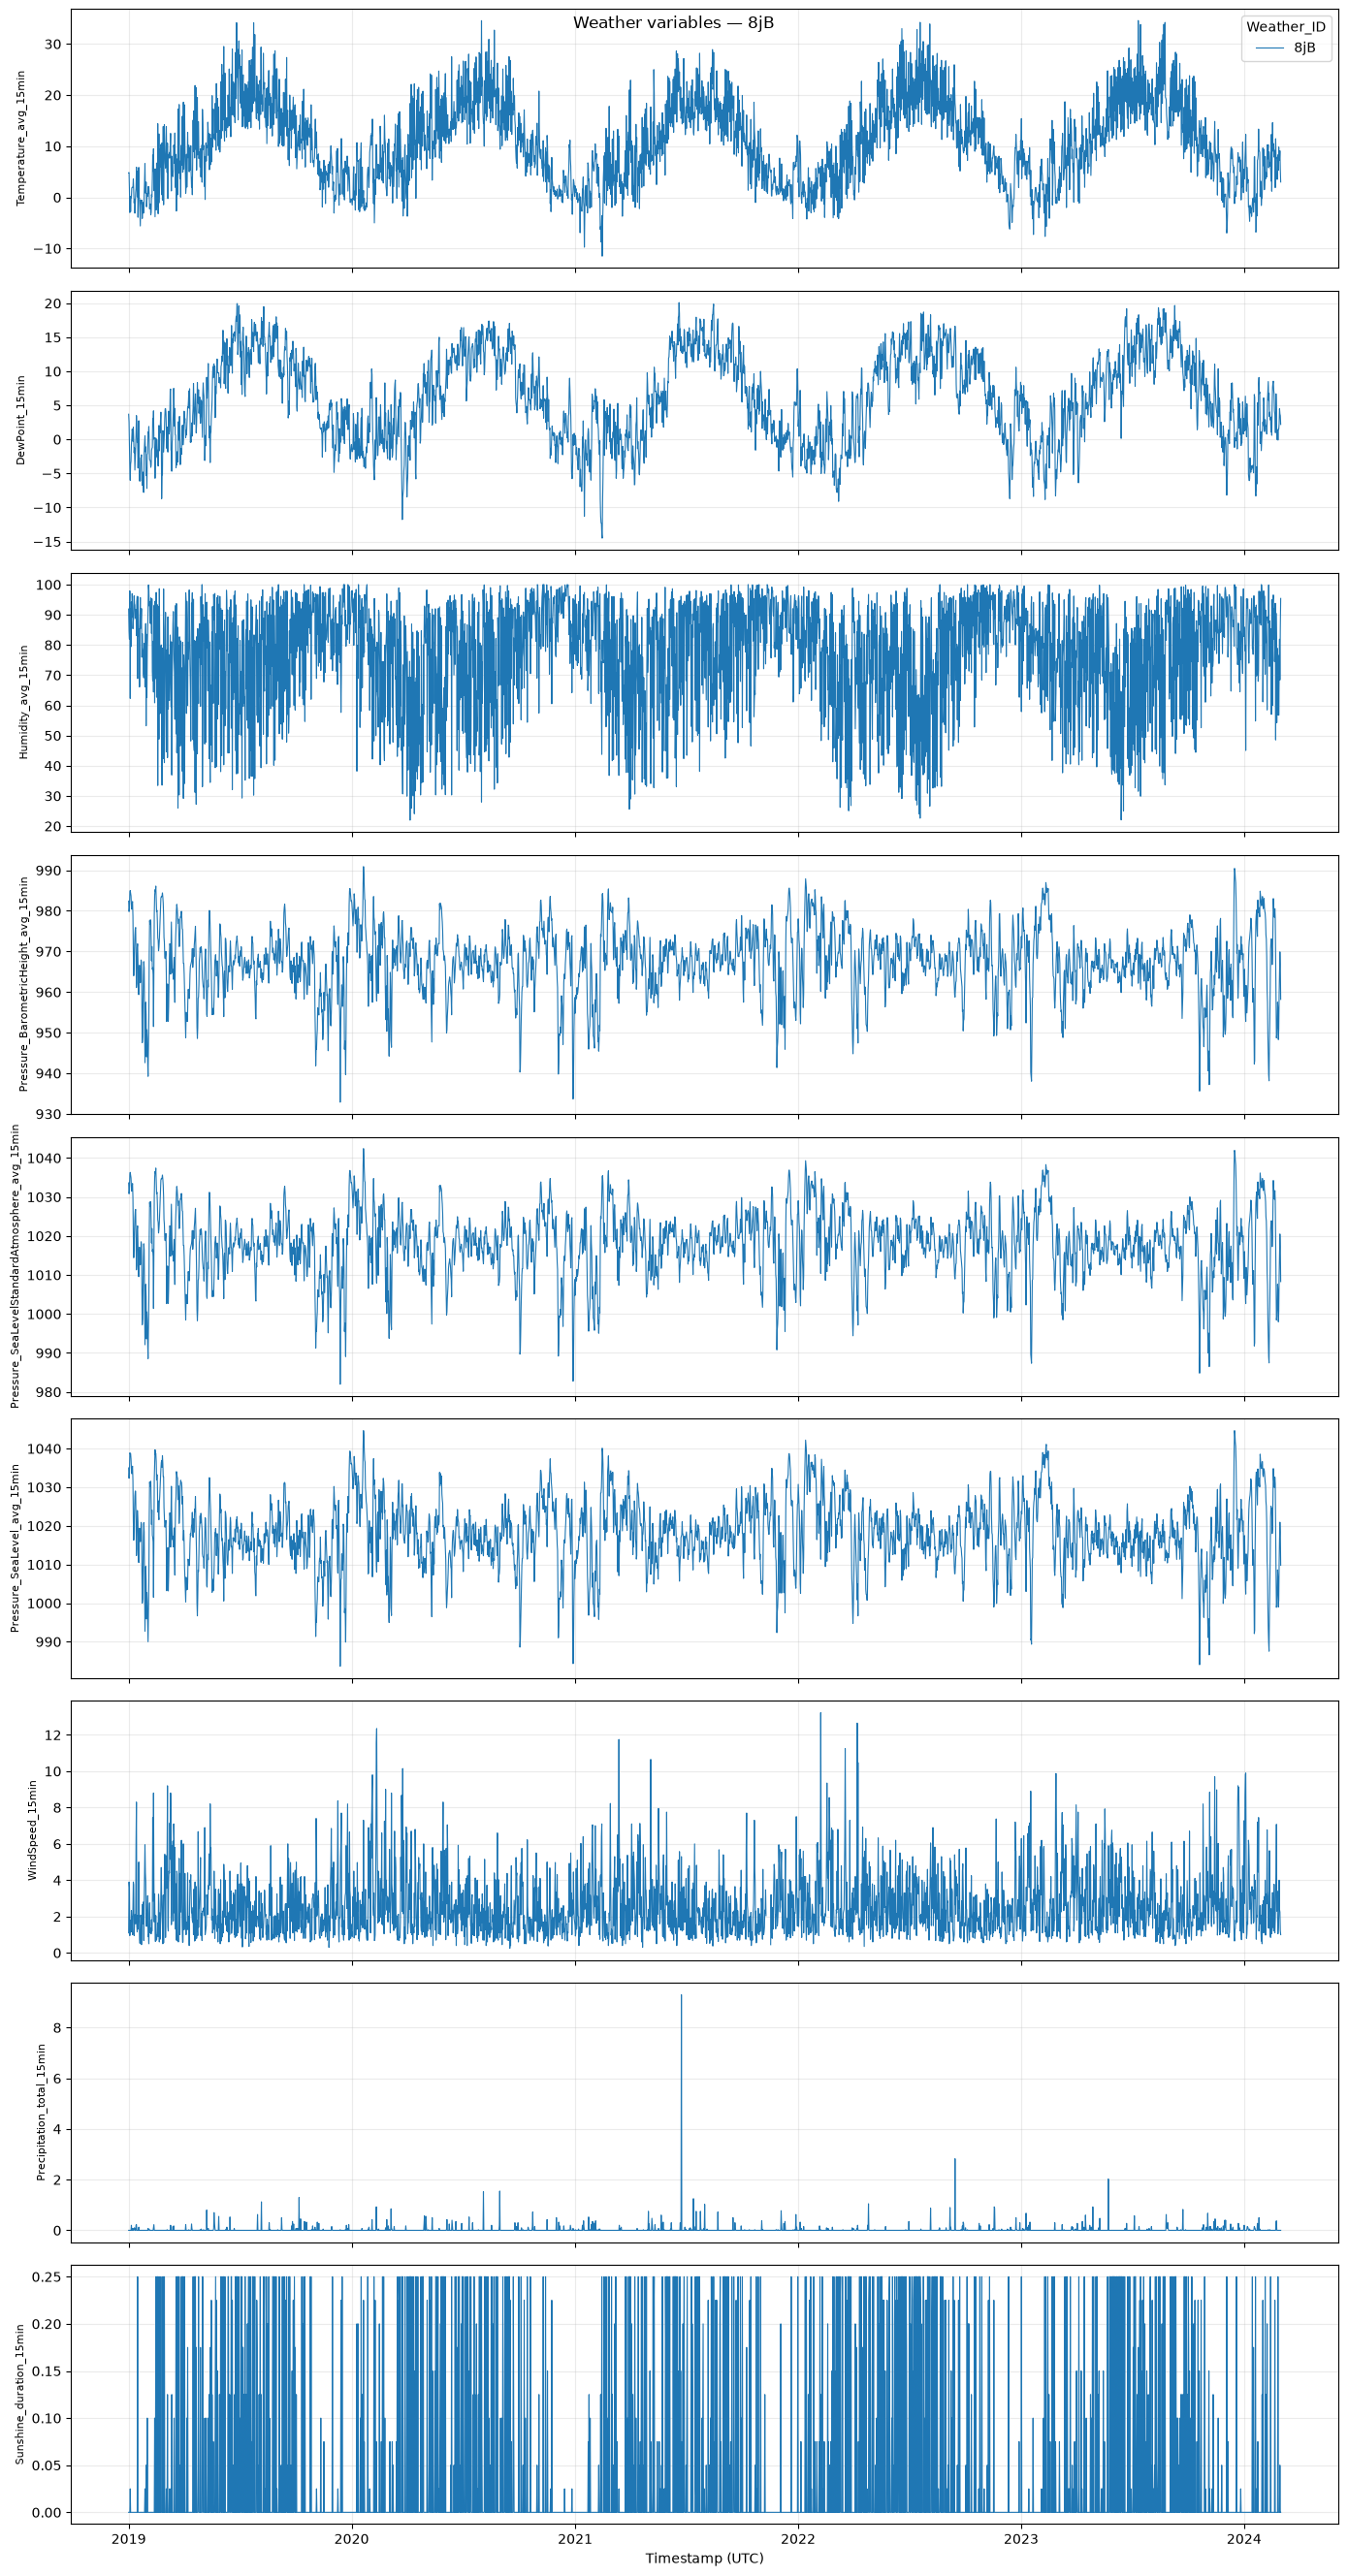

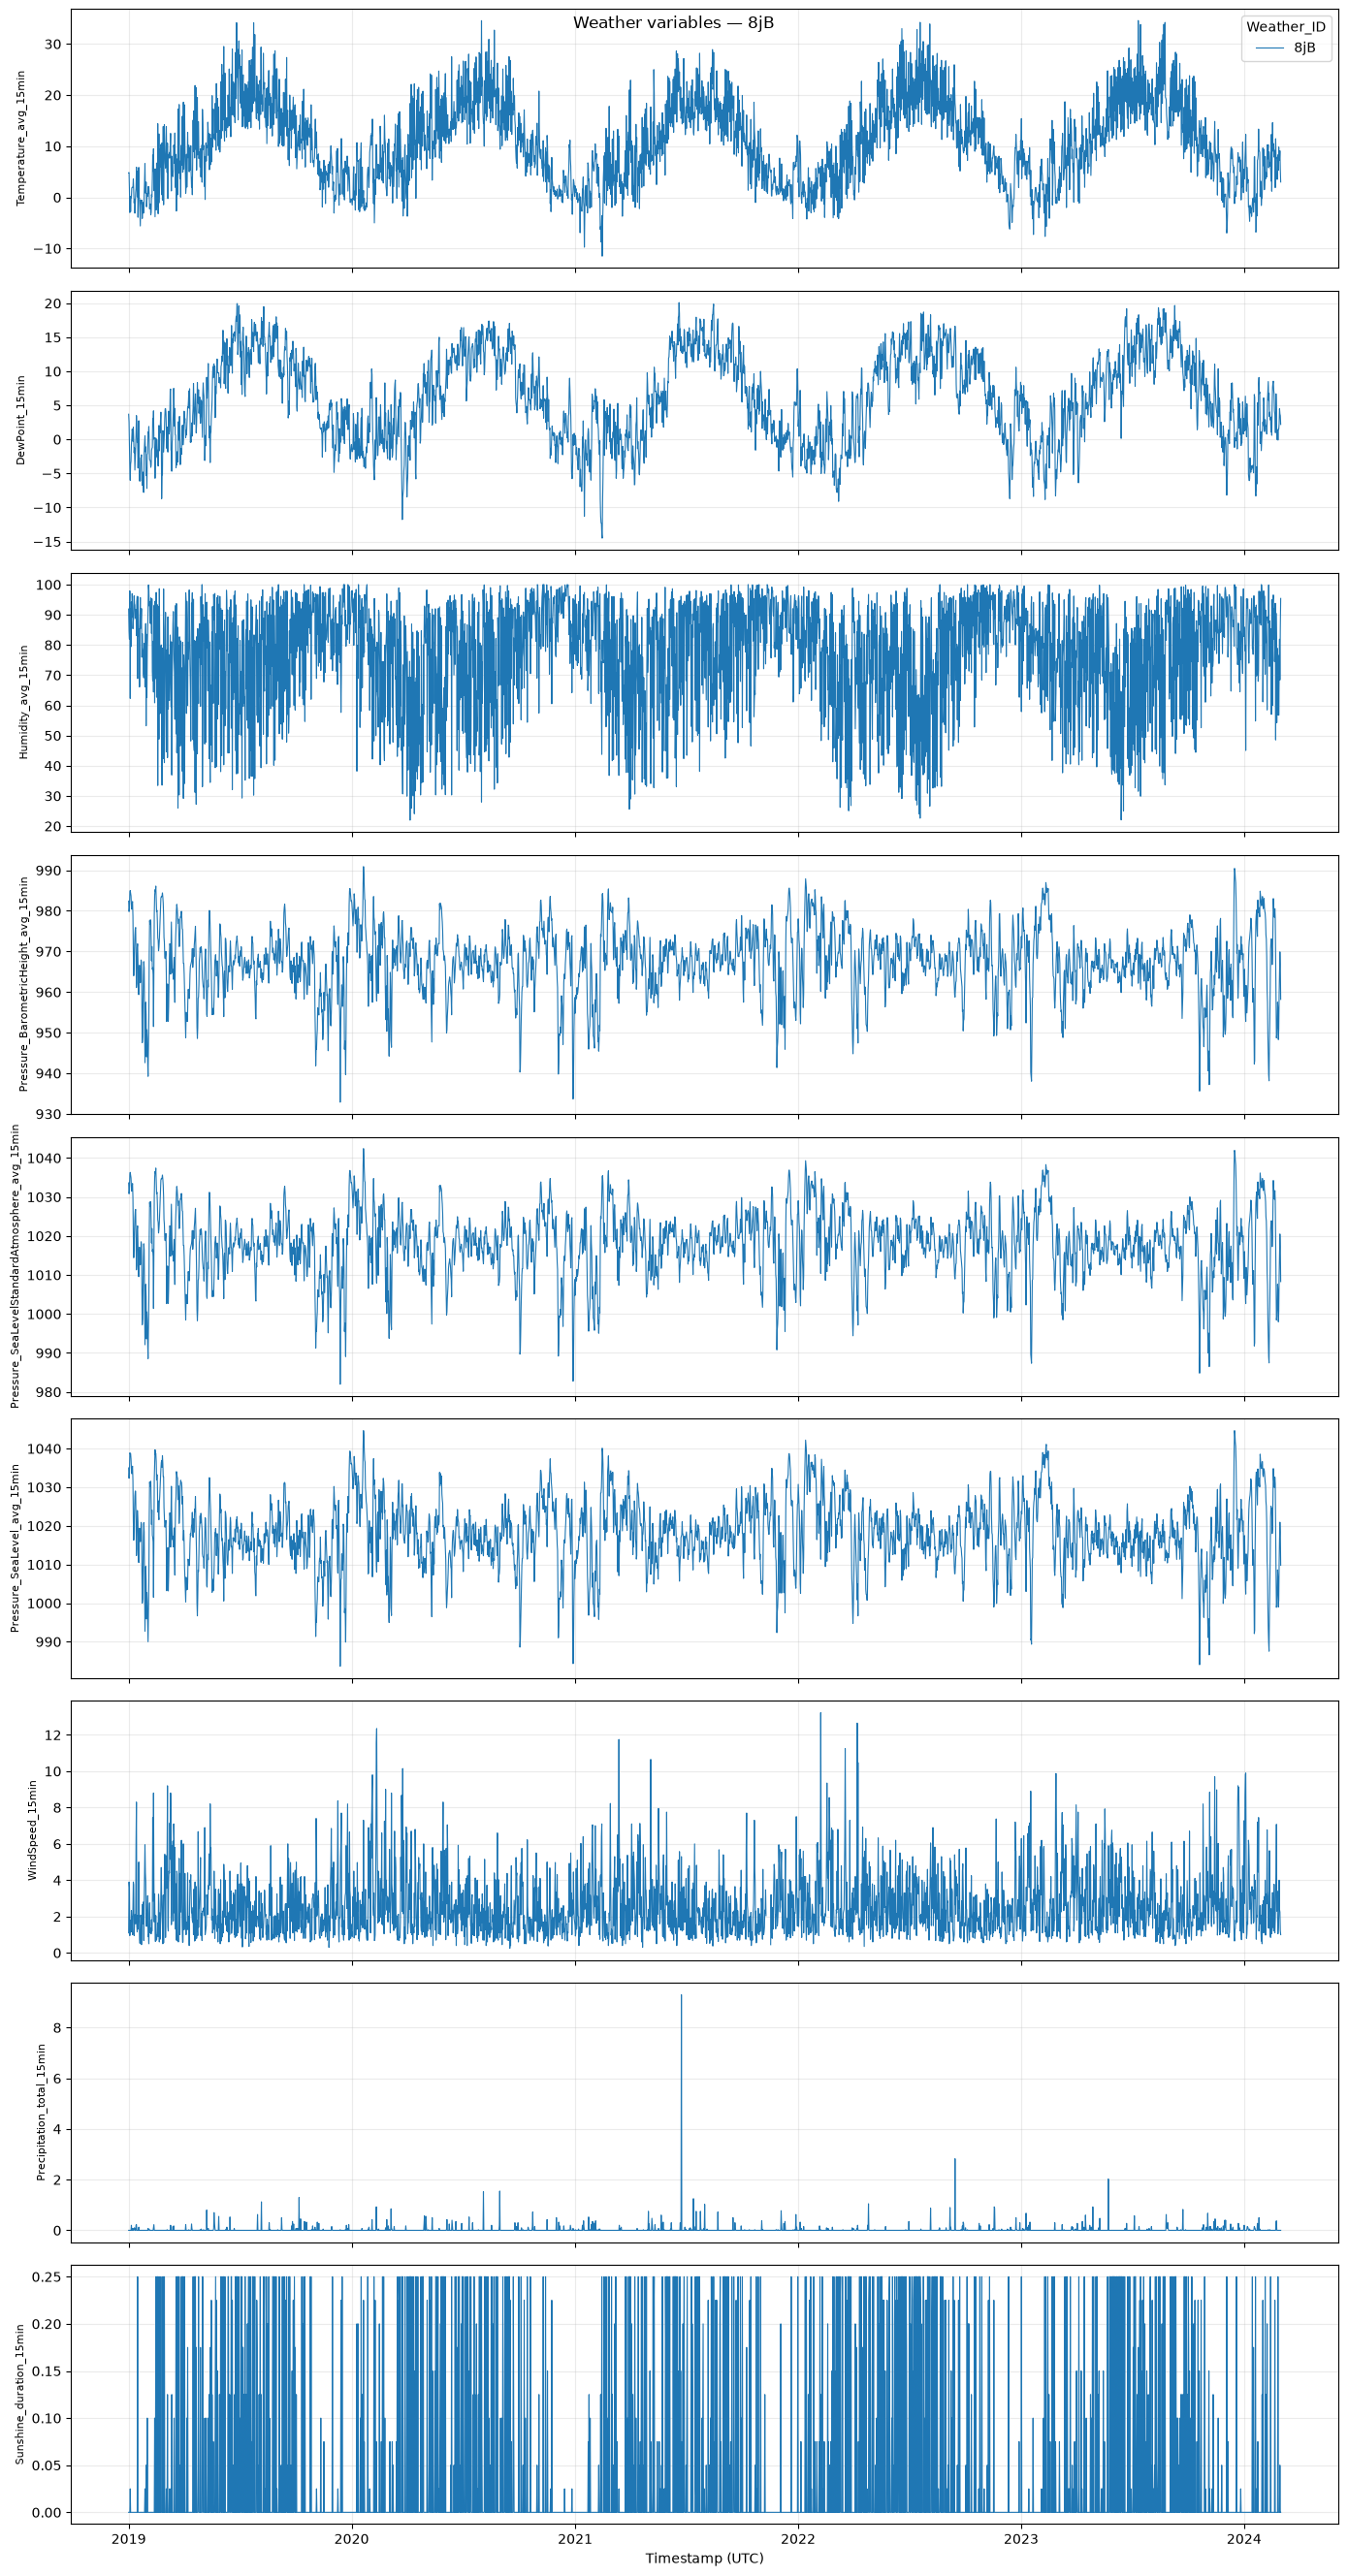

In [8]:
station = weather_15min.Weather_ID.iloc[0]
subset = weather_15min.loc[weather_15min.Weather_ID == station]
display(plot_all_variables_matplotlib(subset, weather_id=station))

### Missing-data coverage across all stations and variables

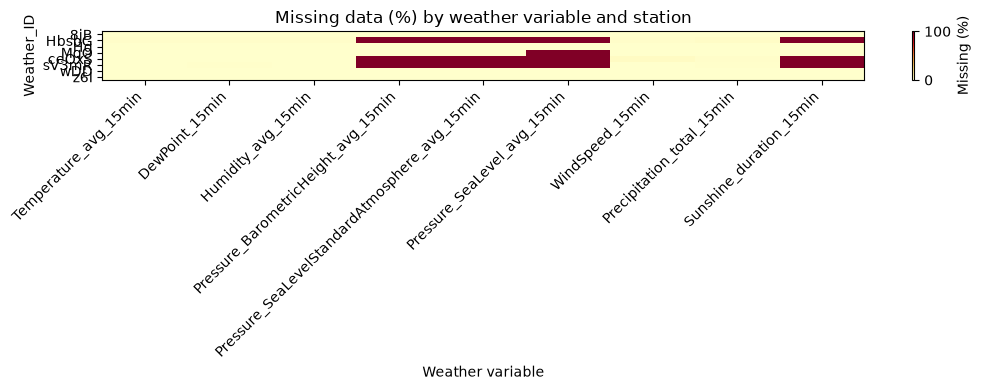

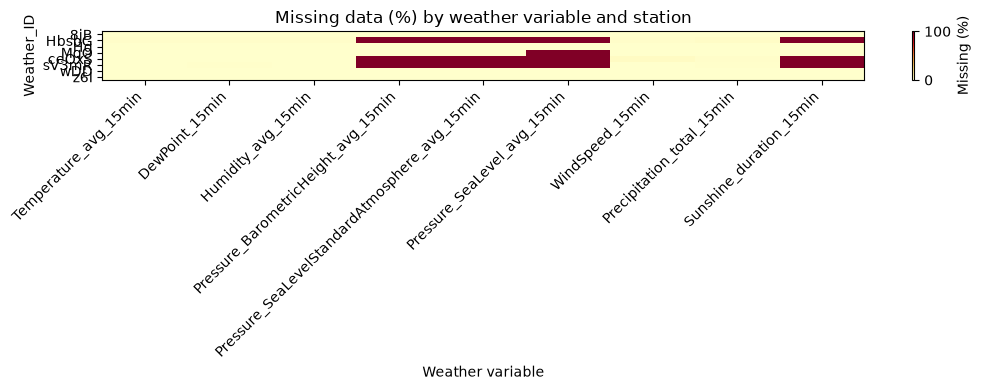

In [9]:
display(plot_variable_coverage_matplotlib(weather_15min))